C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-04-27 20:12:59] [ELAPSED 00:00:00] スクリプト開始
[2026-04-27 20:12:59] [ELAPSED 00:00:00] START TIME = 2026-04-27 20:12:59
[2026-04-27 20:12:59] [ELAPSED 00:00:00] 乱数シード設定: seed=42
[2026-04-27 20:12:59] [ELAPSED 00:00:00] [START] 入力ファイル確認
[2026-04-27 20:12:59] [ELAPSED 00:00:00] 確認OK: ./transactions/txs_features.txt
[2026-04-27 20:12:59] [ELAPSED 00:00:00] 確認OK: ./transactions/txs_classes.txt
[2026-04-27 20:12:59] [ELAPSED 00:00:00] 確認OK: ./transactions/txs_edgelist.txt
[2026-04-27 20:12:59] [ELAPSED 00:00:00] [END] 入力ファイル確認 | phase_elapsed=00:00:00
[2026-04-27 20:12:59] [ELAPSED 00:00:00] [START] 生データ読み込み
[2026-04-27 20:12:59] [ELAPSED 00:00:00] txs_features 読み込み中...
[2026-04-27 20:13:10] [ELAPSED 00:00:10] txs_features 読み込み完了: shape=(203769, 184)
[2026-04-27 20:13:10] [ELAPSED 00:00:10] txs_classes 読み込み中...
[2026-04-27 20:13:10] [ELAPSED 00:00:10] txs_classes 読み込み完了: shape=(203769, 2)
[2026-04-27 20:13:10] [ELAPSED 00:00:10] txs_edgelist 読み込み中...
[2026-04-27 20:13:10] [ELAPSED 00:00:

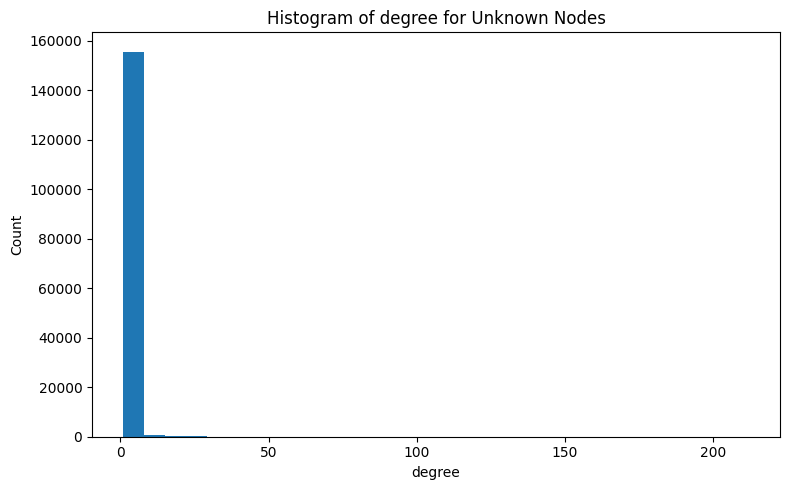

[2026-04-27 20:14:11] [ELAPSED 00:01:12] ヒストグラム描画中: degree_centrality


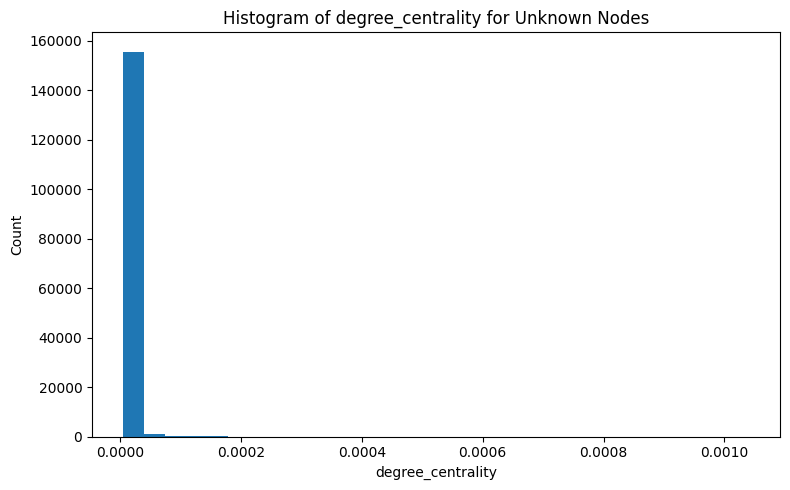

[2026-04-27 20:14:12] [ELAPSED 00:01:12] ヒストグラム描画中: betweenness_centrality


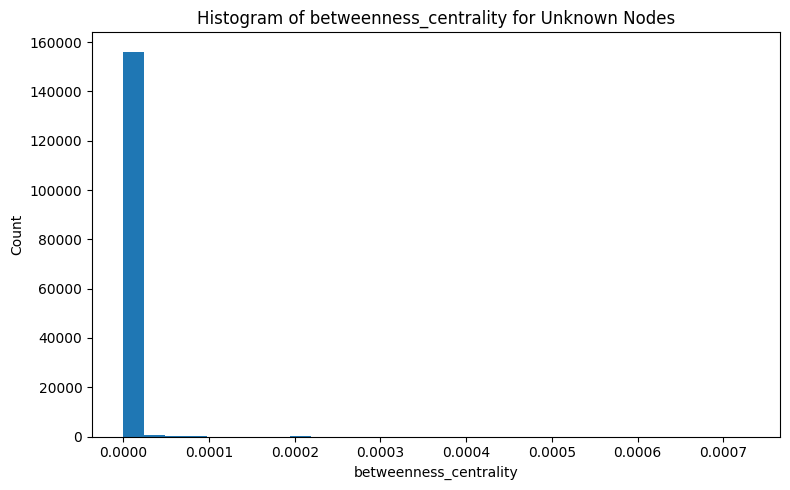

[2026-04-27 20:14:12] [ELAPSED 00:01:12] ヒストグラム描画中: pagerank


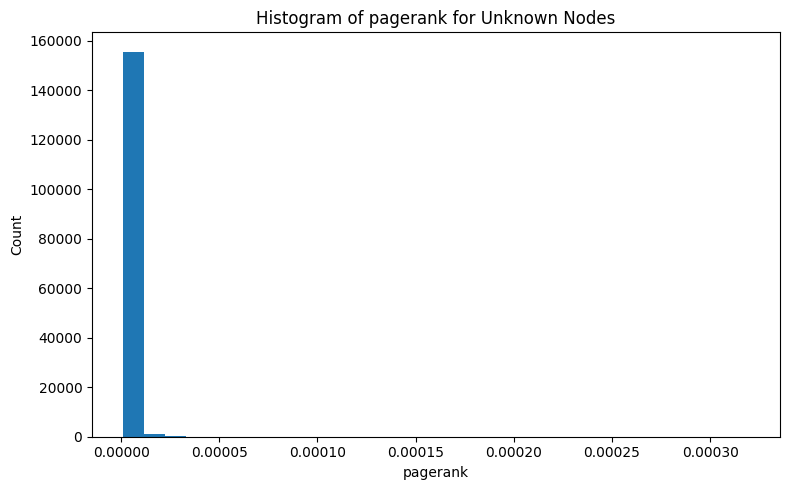

[2026-04-27 20:14:12] [ELAPSED 00:01:12] ヒストグラム描画中: eigenvector_centrality


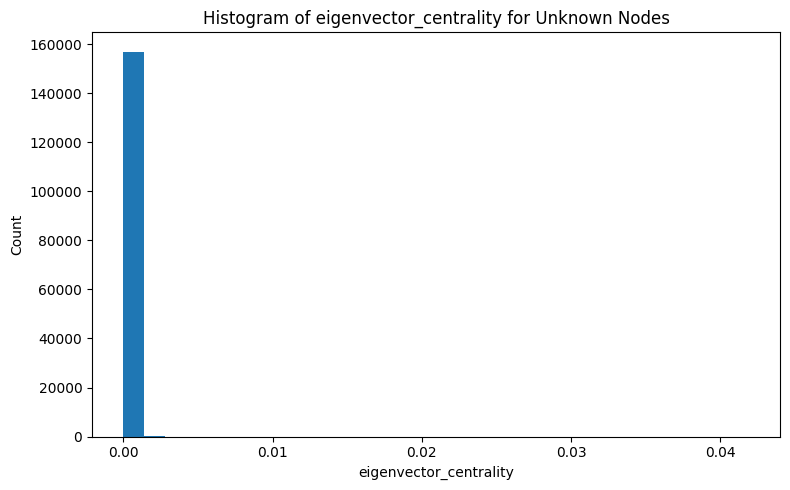

[2026-04-27 20:14:12] [ELAPSED 00:01:13] ヒストグラム描画中: centrality_outlier_score


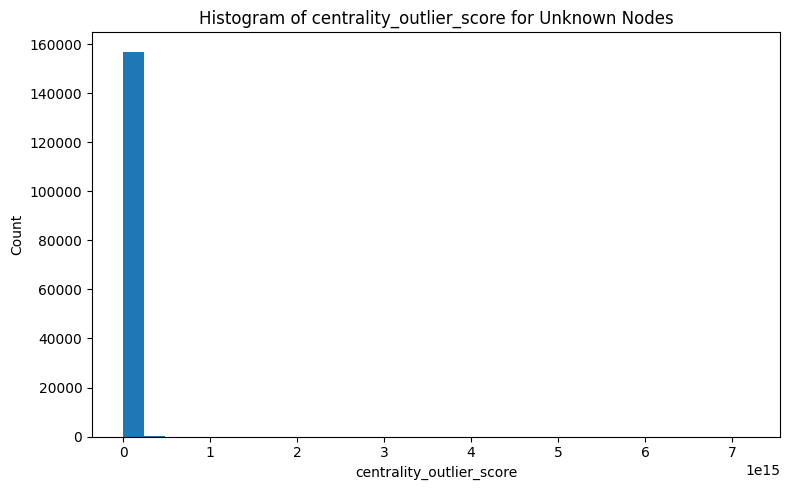

[2026-04-27 20:14:13] [ELAPSED 00:01:13] [END] unknown ノード中心性ヒストグラム | phase_elapsed=00:00:01
[2026-04-27 20:14:13] [ELAPSED 00:01:13] [START] time step ごとの unknown 外れ値集計

=== time step ごとの unknown 外れ値集計 ===
 time_step  unknown_count  outlier_count  avg_degree  max_outlier_score  avg_outlier_score  avg_pagerank  avg_betweenness
         1           5733           5081    2.180359       1.244778e+11       1.117991e+09      0.000005     1.876617e-06
         2           3427            480    2.144733       2.956473e+06       2.434362e+04      0.000005     1.480778e-06
         3           5342           1268    2.526956       7.734402e+09       9.257513e+07      0.000005     5.980302e-06
         4           4253           3352    2.703503       3.778710e+10       1.803143e+09      0.000005     1.807916e-06
         5           4921           4006    2.514326       7.696846e+09       9.679428e+07      0.000005     1.952861e-06
         6           3843           1992    2.369503       1.

In [1]:
# -*- coding: utf-8 -*-

"""
Elliptic++ っぽいトランザクショングラフに対して、
unknown ノード（class=3）を中心性で分析し、
外れ値ノードを検出・ソート表示する完全版。

機能
1) txs_features / txs_classes / txs_edgelist を読み込む
2) class=3 を unknown として扱う
3) PyG Data を構築
4) unknown ノード数を集計
5) 中心性を計算
   - degree
   - degree_centrality
   - betweenness_centrality
   - pagerank
   - eigenvector_centrality
   - closeness_centrality は重いので任意
6) ロバストZスコアで外れ値スコアを作成
7) 外れ値スコア順にソート
8) 外れ値トップを表示
9) CSV保存可能
10) GNN 学習前に y/N 確認
"""

import random
import warnings
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, add_self_loops, to_networkx

warnings.filterwarnings("ignore")


# ==========================
# 設定
# ==========================
TXS_FEATURES = "./transactions/txs_features.txt"
TXS_CLASSES  = "./transactions/txs_classes.txt"
TXS_EDGES    = "./transactions/txs_edgelist.txt"

SEED = 42

INCLUDE_TIME_STEP_AS_FEATURE = False

TOP_K = 10
OUTLIER_TOP_K = 30

ASK_BEFORE_TRAIN = True

# 中心性計算
CALC_CLOSENESS = False
CALC_BETWEENNESS = True
CALC_PAGERANK = True
CALC_EIGENVECTOR = True

USE_APPROX_BETWEENNESS = True
BETWEENNESS_K = 100

EIGENVECTOR_MAX_ITER = 1000

# 外れ値判定
OUTLIER_Z_THRESHOLD = 3.5

# 外れ値スコア
# "max": どれか1つの中心性が極端なら高スコア
# "sum": 複数の中心性が少しずつ異常なら高スコア
OUTLIER_SCORE_MODE = "max"

# ヒストグラム
DRAW_HIST = True
HIST_BINS = 30
FIGSIZE = (8, 5)

# CSV保存
SAVE_CSV = True
OUTPUT_CSV_ALL = "unknown_nodes_centrality_with_outlier_score.csv"
OUTPUT_CSV_OUTLIERS = "unknown_nodes_outliers_sorted.csv"


# ==========================
# ログ
# ==========================
GLOBAL_START_TIME = None


def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def format_seconds(sec: float) -> str:
    sec = int(sec)
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f"{h:02d}:{m:02d}:{s:02d}"


def log(msg: str):
    global GLOBAL_START_TIME
    if GLOBAL_START_TIME is None:
        print(f"[{now_str()}] {msg}")
    else:
        elapsed = time.time() - GLOBAL_START_TIME
        print(f"[{now_str()}] [ELAPSED {format_seconds(elapsed)}] {msg}")


class PhaseTimer:
    def __init__(self, name: str):
        self.name = name
        self.start = None

    def __enter__(self):
        self.start = time.time()
        log(f"[START] {self.name}")
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        elapsed = time.time() - self.start
        log(f"[END] {self.name} | phase_elapsed={format_seconds(elapsed)}")


# ==========================
# 基本
# ==========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    log(f"乱数シード設定: seed={seed}")


def check_files():
    with PhaseTimer("入力ファイル確認"):
        for path in [TXS_FEATURES, TXS_CLASSES, TXS_EDGES]:
            if not Path(path).exists():
                raise FileNotFoundError(f"ファイルが見つかりません: {path}")
            log(f"確認OK: {path}")


def confirm_continue():
    while True:
        ans = input("\nこの後の GNN 処理へ進みますか？ (y/n): ").strip().lower()
        if ans in ["y", "yes"]:
            log("ユーザー入力: y -> 続行")
            return True
        elif ans in ["n", "no"]:
            log("ユーザー入力: n -> 終了")
            return False
        else:
            print("y か n を入力してください。")


def normalize_class_value(v):
    if pd.isna(v):
        return -1

    s = str(v).strip().lower()

    if s in {"1", "illicit"}:
        return 0
    elif s in {"2", "licit"}:
        return 1
    elif s in {"3", "unknown"}:
        return -1
    else:
        return -1


# ==========================
# 読み込み
# ==========================
def load_raw_data():
    with PhaseTimer("生データ読み込み"):
        log("txs_features 読み込み中...")
        df_features = pd.read_csv(TXS_FEATURES)
        log(f"txs_features 読み込み完了: shape={df_features.shape}")

        log("txs_classes 読み込み中...")
        df_classes = pd.read_csv(TXS_CLASSES)
        log(f"txs_classes 読み込み完了: shape={df_classes.shape}")

        log("txs_edgelist 読み込み中...")
        df_edges = pd.read_csv(TXS_EDGES)
        log(f"txs_edgelist 読み込み完了: shape={df_edges.shape}")

        print("\n=== Features overview ===")
        print(df_features.head())
        print("missing values total:", int(df_features.isnull().sum().sum()))

        print("\n=== Classes overview ===")
        if "class" in df_classes.columns:
            print(df_classes["class"].value_counts(dropna=False))

        print("\n=== Edges overview ===")
        print(df_edges.head())
        print("duplicate edges:", int(df_edges.duplicated().sum()))

        return df_features, df_classes, df_edges


# ==========================
# PyG Data 構築
# ==========================
def build_pyg_data(
    df_features: pd.DataFrame,
    df_classes: pd.DataFrame,
    df_edges: pd.DataFrame,
    include_time_step_as_feature: bool = False
):
    with PhaseTimer("PyG Data 構築"):
        id_col_feat = df_features.columns[0]
        log(f"ノードID列: {id_col_feat}")

        if "Time step" not in df_features.columns:
            raise ValueError("df_features に 'Time step' 列がありません。")

        time_steps_np = pd.to_numeric(
            df_features["Time step"],
            errors="coerce"
        ).fillna(-1).to_numpy(dtype=np.int64)

        time_steps = torch.tensor(time_steps_np, dtype=torch.long)

        log(
            f"time step 範囲: "
            f"min={int(time_steps.min().item())}, "
            f"max={int(time_steps.max().item())}"
        )

        feature_cols = [c for c in df_features.columns if c != id_col_feat]

        if not include_time_step_as_feature:
            feature_cols = [c for c in feature_cols if c != "Time step"]

        log(f"特徴量列数: {len(feature_cols)}")

        x_df = df_features[feature_cols].copy()
        x_df = x_df.apply(pd.to_numeric, errors="coerce")
        x_df = x_df.replace([np.inf, -np.inf], np.nan)
        x_df = x_df.fillna(0.0)

        x_np = x_df.to_numpy(dtype=np.float32)
        x = torch.tensor(x_np, dtype=torch.float)

        log(f"x shape: {tuple(x.shape)}")
        log(f"x NaN: {torch.isnan(x).any().item()}")
        log(f"x Inf: {torch.isinf(x).any().item()}")

        if "class" not in df_classes.columns:
            raise ValueError("df_classes に 'class' 列がありません。")

        if id_col_feat in df_classes.columns:
            id_col_cls = id_col_feat
        else:
            id_col_cls = df_classes.columns[0]
            log(f"class 側 ID 列として '{id_col_cls}' を使用")

        node_ids = df_features[id_col_feat].astype(int).values
        id2idx = {int(nid): i for i, nid in enumerate(node_ids)}

        log(f"ノード数: {len(node_ids)}")

        cls_series = (
            df_classes
            .set_index(id_col_cls)["class"]
            .reindex(node_ids)
        )

        y_np = cls_series.map(normalize_class_value).to_numpy(dtype=np.int64)
        y = torch.tensor(y_np, dtype=torch.long)

        log("ラベル分布:")
        print(pd.Series(y_np).value_counts(dropna=False).sort_index())

        edge_cols = list(df_edges.columns[:2])
        src_raw = df_edges[edge_cols[0]].values
        dst_raw = df_edges[edge_cols[1]].values

        src_idx = []
        dst_idx = []
        missing_edges = 0

        log(f"元エッジ数: {len(src_raw)}")

        for i, (u, v) in enumerate(zip(src_raw, dst_raw), start=1):
            u = int(u)
            v = int(v)

            if u in id2idx and v in id2idx:
                src_idx.append(id2idx[u])
                dst_idx.append(id2idx[v])
            else:
                missing_edges += 1

            if i % 500000 == 0:
                log(f"エッジ変換進捗: {i}/{len(src_raw)}")

        edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)
        edge_index = to_undirected(edge_index, num_nodes=len(node_ids))
        edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

        log(f"edge_index shape: {tuple(edge_index.shape)}")
        log(f"スキップされたエッジ数: {missing_edges}")

        data = Data(x=x, edge_index=edge_index, y=y)
        data.time_steps = time_steps
        data.node_ids = torch.tensor(node_ids, dtype=torch.long)

        return data


# ==========================
# ロバストZスコア
# ==========================
def robust_z_score(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce").fillna(0.0)

    median = s.median()
    mad = (s - median).abs().median()

    if mad == 0:
        std = s.std()
        if std == 0 or pd.isna(std):
            return pd.Series(0.0, index=s.index)
        return (s - s.mean()) / std

    return 0.6745 * (s - median) / mad


# ==========================
# 外れ値スコア追加
# ==========================
def add_centrality_outlier_scores(
    df_unknown: pd.DataFrame,
    threshold: float = 3.5,
    score_mode: str = "max"
):
    with PhaseTimer("中心性外れ値スコア計算"):
        centrality_cols = []

        candidate_cols = [
            "degree",
            "degree_centrality",
            "closeness_centrality",
            "betweenness_centrality",
            "pagerank",
            "eigenvector_centrality",
        ]

        for col in candidate_cols:
            if col in df_unknown.columns:
                centrality_cols.append(col)

        log(f"外れ値判定に使う中心性: {centrality_cols}")

        rz_cols = []

        for col in centrality_cols:
            rz_col = col + "_rz"
            abs_col = col + "_abs_rz"

            df_unknown[rz_col] = robust_z_score(df_unknown[col])
            df_unknown[abs_col] = df_unknown[rz_col].abs()

            rz_cols.append(rz_col)

            log(f"ロバストZスコア作成: {col} -> {rz_col}")

        abs_rz_cols = [c.replace("_rz", "_abs_rz") for c in rz_cols]

        if score_mode == "sum":
            df_unknown["centrality_outlier_score"] = df_unknown[abs_rz_cols].sum(axis=1)
        else:
            df_unknown["centrality_outlier_score"] = df_unknown[abs_rz_cols].max(axis=1)

        df_unknown["is_outlier"] = (
            df_unknown["centrality_outlier_score"] >= threshold
        )

        max_col = df_unknown[abs_rz_cols].idxmax(axis=1)
        df_unknown["outlier_reason"] = (
            max_col
            .str.replace("_abs_rz", "", regex=False)
        )

        log(f"外れ値しきい値: {threshold}")
        log(f"外れ値スコア方式: {score_mode}")
        log(f"外れ値ノード数: {int(df_unknown['is_outlier'].sum())}")

        df_sorted = df_unknown.sort_values(
            ["centrality_outlier_score", "degree", "pagerank" if "pagerank" in df_unknown.columns else "node_index"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

        return df_sorted


# ==========================
# unknown ノード中心性分析
# ==========================
def analyze_unknown_nodes_with_centrality_and_outliers(
    data: Data,
    top_k: int = 10,
    outlier_top_k: int = 30
):
    with PhaseTimer("unknown ノード中心性分析"):
        log("NetworkX グラフへ変換中...")
        G = to_networkx(data.cpu(), to_undirected=True)

        log(
            f"NetworkX グラフ変換完了: "
            f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}"
        )

        log("自己ループ削除中...")
        G.remove_edges_from(nx.selfloop_edges(G))
        log(f"自己ループ削除後: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

        y = data.y.cpu().numpy()
        node_ids = data.node_ids.cpu().numpy()
        time_steps = data.time_steps.cpu().numpy()

        unknown_nodes = np.where(y == -1)[0]
        n_unknown = len(unknown_nodes)

        log(f"unknown ノード数: {n_unknown}")

        if n_unknown == 0:
            print("unknown ノードは存在しません。")
            return pd.DataFrame(), G

        log("次数を取得中...")
        degree_dict = dict(G.degree())
        log("次数取得完了")

        log("次数中心性を計算中...")
        degree_cent = nx.degree_centrality(G)
        log("次数中心性 計算完了")

        closeness_cent = None
        if CALC_CLOSENESS:
            log("近接中心性を計算中... 大規模グラフでは非常に重い可能性があります")
            closeness_cent = nx.closeness_centrality(G)
            log("近接中心性 計算完了")

        betweenness_cent = None
        if CALC_BETWEENNESS:
            if USE_APPROX_BETWEENNESS:
                log(f"媒介中心性を近似計算中... k={BETWEENNESS_K}")
                betweenness_cent = nx.betweenness_centrality(
                    G,
                    k=BETWEENNESS_K,
                    seed=SEED
                )
                log("媒介中心性 近似計算完了")
            else:
                log("媒介中心性を厳密計算中... 非常に重い可能性があります")
                betweenness_cent = nx.betweenness_centrality(G)
                log("媒介中心性 厳密計算完了")

        pagerank_cent = None
        if CALC_PAGERANK:
            log("PageRank を計算中...")
            pagerank_cent = nx.pagerank(G)
            log("PageRank 計算完了")

        eigenvector_cent = None
        if CALC_EIGENVECTOR:
            log("固有ベクトル中心性を計算中...")
            try:
                eigenvector_cent = nx.eigenvector_centrality(
                    G,
                    max_iter=EIGENVECTOR_MAX_ITER
                )
                log("固有ベクトル中心性 計算完了")
            except Exception as e:
                log(f"固有ベクトル中心性が収束しませんでした: {e}")
                log("固有ベクトル中心性は 0 扱いにします")
                eigenvector_cent = {n: 0.0 for n in G.nodes()}

        rows = []

        log("unknown ノードごとの中心性テーブル作成中...")

        for i, n in enumerate(unknown_nodes, start=1):
            row = {
                "node_index": int(n),
                "txId": int(node_ids[n]),
                "time_step": int(time_steps[n]),
                "degree": int(degree_dict.get(n, 0)),
                "degree_centrality": float(degree_cent.get(n, 0.0)),
            }

            if closeness_cent is not None:
                row["closeness_centrality"] = float(closeness_cent.get(n, 0.0))

            if betweenness_cent is not None:
                row["betweenness_centrality"] = float(betweenness_cent.get(n, 0.0))

            if pagerank_cent is not None:
                row["pagerank"] = float(pagerank_cent.get(n, 0.0))

            if eigenvector_cent is not None:
                row["eigenvector_centrality"] = float(eigenvector_cent.get(n, 0.0))

            rows.append(row)

            if i % 10000 == 0:
                log(f"unknown ノード集計進捗: {i}/{n_unknown}")

        df_unknown = pd.DataFrame(rows)

        log(f"unknown 中心性テーブル完成: shape={df_unknown.shape}")

        df_sorted = add_centrality_outlier_scores(
            df_unknown=df_unknown,
            threshold=OUTLIER_Z_THRESHOLD,
            score_mode=OUTLIER_SCORE_MODE
        )

        print(f"\n=== unknown ノード 外れ値トップ{min(outlier_top_k, len(df_sorted))} ===")
        display_cols = [
            "node_index",
            "txId",
            "time_step",
            "degree",
            "degree_centrality",
            "centrality_outlier_score",
            "is_outlier",
            "outlier_reason",
        ]

        for c in [
            "betweenness_centrality",
            "pagerank",
            "eigenvector_centrality",
            "closeness_centrality",
        ]:
            if c in df_sorted.columns:
                display_cols.insert(-3, c)

        print(
            df_sorted[display_cols]
            .head(outlier_top_k)
            .to_string(index=False)
        )

        print(f"\n=== unknown ノード 次数トップ{min(top_k, len(df_sorted))} ===")
        print(
            df_sorted.sort_values("degree", ascending=False)
            .head(top_k)
            .to_string(index=False)
        )

        if "betweenness_centrality" in df_sorted.columns:
            print(f"\n=== unknown ノード 媒介中心性トップ{min(top_k, len(df_sorted))} ===")
            print(
                df_sorted.sort_values("betweenness_centrality", ascending=False)
                .head(top_k)
                .to_string(index=False)
            )

        if "pagerank" in df_sorted.columns:
            print(f"\n=== unknown ノード PageRankトップ{min(top_k, len(df_sorted))} ===")
            print(
                df_sorted.sort_values("pagerank", ascending=False)
                .head(top_k)
                .to_string(index=False)
            )

        print("\n=== unknown ノード中心性・外れ値スコアの基本統計 ===")
        stat_cols = [
            c for c in [
                "degree",
                "degree_centrality",
                "closeness_centrality",
                "betweenness_centrality",
                "pagerank",
                "eigenvector_centrality",
                "centrality_outlier_score",
            ]
            if c in df_sorted.columns
        ]

        print(df_sorted[stat_cols].describe())

        return df_sorted, G


# ==========================
# ヒストグラム
# ==========================
def plot_unknown_centrality_histograms(df_unknown: pd.DataFrame):
    if len(df_unknown) == 0:
        log("ヒストグラム描画スキップ: unknown ノードなし")
        return

    with PhaseTimer("unknown ノード中心性ヒストグラム"):
        cols = [
            c for c in [
                "degree",
                "degree_centrality",
                "closeness_centrality",
                "betweenness_centrality",
                "pagerank",
                "eigenvector_centrality",
                "centrality_outlier_score",
            ]
            if c in df_unknown.columns
        ]

        for col in cols:
            log(f"ヒストグラム描画中: {col}")
            plt.figure(figsize=FIGSIZE)
            plt.hist(df_unknown[col], bins=HIST_BINS)
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.title(f"Histogram of {col} for Unknown Nodes")
            plt.tight_layout()
            plt.show()


# ==========================
# time step 集計
# ==========================
def summarize_unknown_by_time_step(df_unknown: pd.DataFrame):
    if len(df_unknown) == 0:
        log("time step 集計スキップ: unknown ノードなし")
        return

    with PhaseTimer("time step ごとの unknown 外れ値集計"):
        agg_dict = {
            "unknown_count": ("node_index", "count"),
            "outlier_count": ("is_outlier", "sum"),
            "avg_degree": ("degree", "mean"),
            "max_outlier_score": ("centrality_outlier_score", "max"),
            "avg_outlier_score": ("centrality_outlier_score", "mean"),
        }

        if "pagerank" in df_unknown.columns:
            agg_dict["avg_pagerank"] = ("pagerank", "mean")

        if "betweenness_centrality" in df_unknown.columns:
            agg_dict["avg_betweenness"] = ("betweenness_centrality", "mean")

        summary = (
            df_unknown.groupby("time_step")
            .agg(**agg_dict)
            .reset_index()
            .sort_values("time_step")
        )

        print("\n=== time step ごとの unknown 外れ値集計 ===")
        print(summary.to_string(index=False))


# ==========================
# CSV保存
# ==========================
def save_outputs(df_sorted: pd.DataFrame):
    if len(df_sorted) == 0:
        log("CSV保存スキップ: データなし")
        return

    with PhaseTimer("CSV保存"):
        df_sorted.to_csv(
            OUTPUT_CSV_ALL,
            index=False,
            encoding="utf-8-sig"
        )

        df_outliers = df_sorted[df_sorted["is_outlier"]].copy()

        df_outliers.to_csv(
            OUTPUT_CSV_OUTLIERS,
            index=False,
            encoding="utf-8-sig"
        )

        log(f"全unknownノードCSV保存: {OUTPUT_CSV_ALL}")
        log(f"外れ値ノードCSV保存: {OUTPUT_CSV_OUTLIERS}")
        log(f"外れ値ノード数: {len(df_outliers)}")


# ==========================
# main
# ==========================
def main():
    global GLOBAL_START_TIME
    GLOBAL_START_TIME = time.time()

    log("スクリプト開始")
    log(f"START TIME = {now_str()}")

    set_seed(SEED)
    check_files()

    df_features, df_classes, df_edges = load_raw_data()

    data = build_pyg_data(
        df_features=df_features,
        df_classes=df_classes,
        df_edges=df_edges,
        include_time_step_as_feature=INCLUDE_TIME_STEP_AS_FEATURE
    )

    df_unknown_sorted, G = analyze_unknown_nodes_with_centrality_and_outliers(
        data=data,
        top_k=TOP_K,
        outlier_top_k=OUTLIER_TOP_K
    )

    if SAVE_CSV:
        save_outputs(df_unknown_sorted)

    if DRAW_HIST:
        plot_unknown_centrality_histograms(df_unknown_sorted)

    summarize_unknown_by_time_step(df_unknown_sorted)

    if ASK_BEFORE_TRAIN:
        if not confirm_continue():
            total_elapsed = time.time() - GLOBAL_START_TIME
            log(f"ここで終了します。総経過時間={format_seconds(total_elapsed)}")
            return

    log("この先に GNN 学習処理を接続できます。")

    total_elapsed = time.time() - GLOBAL_START_TIME
    log(f"Done. 総経過時間={format_seconds(total_elapsed)}")


if __name__ == "__main__":
    main()